In [1]:
from Functions import utils as u

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Obtain Data

In [2]:
data = u.extract_data(UMP_threshold=-3.0)

display(data)

#features_and_label = ['Teff','logg','bp_rp_dered','e_bv', 'NUVDered','UMP_flag']
features_and_label = ['Teff','logg', 'bp_rp_dered','e_bv', 'colorColorY','UMP_flag']
selected_data = data[features_and_label].copy()

#remove all rows where logg is Nan
selected_data = selected_data.dropna(subset=['e_bv'])

print(f"Num of UMPs: {len(selected_data[selected_data['UMP_flag']==1])}, Num of non-UMPs:{len(selected_data[selected_data['UMP_flag']!=1])}")

print(f'EMP fraction = {len(selected_data[selected_data['UMP_flag']==1])/len(selected_data)}')



mask_nuv = selected_data['colorColorY'] >= -700
removed_outliers = (~mask_nuv).sum()
selected_data = selected_data.loc[mask_nuv].copy()
print(f"Removed {removed_outliers} rows with NUVDered < -500; remaining {len(selected_data)} rows")


,Survey,FeH,NUVDered,bp_rp_dered,e_bv,Teff,logg,colorColorY,UMP_flag
0,Bonifacio,-2.83,20.194627,1.003094,0.060031,6303.000000,4.2500,-1.016775,0
1,Cayrel,-2.09,13.763638,0.878489,0.059608,5250.000000,2.0000,-1.077013,0
2,Cayrel,-3.06,13.687658,1.019055,0.193103,19883.960938,3.8566,-1.862718,1
3,Cayrel,-3.71,17.854393,0.883936,0.017698,5250.000000,3.0000,-1.778273,1
4,Cayrel,-3.35,19.073609,1.022003,0.027137,5456.290527,2.7236,-1.514804,1
...,...,...,...,...,...,...,...,...,...
588,Yong,-2.60,18.570030,0.582178,0.027532,6507.000000,4.2900,-1.297989,0
589,Yong,-2.65,17.412597,0.570395,0.018709,6624.000000,4.1100,-1.041163,0
590,Yong,-2.60,18.019629,0.580172,0.027431,6479.000000,4.3100,-1.252573,0
591,Yong,-2.68,18.129256,0.664409,0.017284,6196.000000,3.7700,-1.605187,0


Num of UMPs: 196, Num of non-UMPs:397
EMP fraction = 0.3305227655986509
Removed 6 rows with NUVDered < -500; remaining 587 rows


# Scale and Split, Select if you wish to include SMOTE

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
from imblearn.under_sampling import EditedNearestNeighbours



def scale_and_split(data, target_column, test_size=0.2, random_state=42, use_smote = False):
    """
    Splits the dataset into training and validation sets, and scales the features.

    Parameters:
    - data: pd.DataFrame
    - target_column: str, name of the target column
    - test_size: float, proportion of validation set
    - random_state: int, for reproducibility

    Returns:
    - X_train_scaled, X_val_scaled, y_train, y_val, scaler
    """
    # Separate features and target
    X = data.drop(columns=[target_column]).copy()
    y = data[target_column].copy()

    # Split into train and validation
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )
    
    #Resample with smote if True
    if use_smote:
        smote = SMOTEENN(
            sampling_strategy={0:500,1: 400},
            random_state=random_state)
        X_train, y_train = smote.fit_resample(X_train, y_train)

    #Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    return X_train_scaled, X_val_scaled, y_train, y_val, scaler

x_train, x_val, y_train, y_val,scaler= scale_and_split(selected_data, 'UMP_flag', use_smote=True)




# Logistic Regression

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_halving_search_cv  # noqa
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_recall_curve, 
    precision_score, recall_score, confusion_matrix, 
    ConfusionMatrixDisplay
)
from imblearn.combine import SMOTEENN

from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours





def UMP_predictor_model(X_train, y_train, X_valid, y_valid, target_precision=0.90):
    """
    Logistic Regression optimized for high precision using SMOTEENN + threshold tuning.
    """

    # -------------------------
    # 3. Model + Halving Grid Search
    # -------------------------
    model = LogisticRegression(
        #class_weight={0:1,1:3},
        class_weight='balanced',
        solver='lbfgs',
        max_iter=10000
    )

    param_grid = {
        'C': np.logspace(-1, 2, 30), 
        #'class_weight':[{0:1,1:50},{0:1,1:500},{0:1,1:10},{0:1,1:25},{0:1,1:100}]
        }

    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='precision',
        cv=5,
        factor=3,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    print(f"\nBest C: {search.best_params_['C']:.5f}")

    # -------------------------
    # 4. Validation Predictions
    # -------------------------
    y_probs = best_model.predict_proba(X_valid)[:, 1]

    # Compute precision-recall pairs
    precisions, recalls, thresholds = precision_recall_curve(y_valid, y_probs)

    # Select threshold: highest recall among thresholds meeting target precision

    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    mask = recalls >= 0.2
    best_index = np.argmax(f1_scores)
    best_threshold = thresholds[best_index] if best_index < len(thresholds) else 0.5

    print(f"Selected Threshold = {best_threshold:.3f}")

    y_pred = (y_probs >= best_threshold).astype(int)

    # -------------------------
    # 5. Evaluation Metrics
    # -------------------------
    print(f"Precision: {precision_score(y_valid, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_valid, y_pred):.4f}")

    cm = confusion_matrix(y_valid, y_pred)
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
    plt.show()

    # -------------------------
    # 6. Precision vs C Plot
    # -------------------------
    mean_test_scores = search.cv_results_['mean_test_score']
    C_values = search.cv_results_['param_C'].data.astype(float)

    plt.figure(figsize=(7, 5))
    plt.semilogx(C_values, mean_test_scores, marker='o')
    plt.xlabel("Regularization Strength C (log scale)")
    plt.ylabel("CV Precision")
    plt.title("Precision vs Regularization Strength (C)")
    plt.grid(True)
    plt.show()

    # -------------------------
    # 7. Precision-Recall Curve
    # -------------------------
    plt.figure(figsize=(7, 5))
    plt.plot(recalls, precisions)
    
    plt.scatter(recalls[best_index], precisions[best_index], color='red', s=80,
                label=f"Best Threshold = {best_threshold:.3f}")
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.ylim(0,1)
    plt.title("Precision–Recall Curve")
    plt.grid(True)
    plt.show()

    return best_model, best_threshold


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer, average_precision_score
)

def UMP_predictor_model(X_train, y_train, X_val, y_val):
    # ---- Base Logistic Regression Model ----
    model = LogisticRegression(random_state=42, solver="lbfgs")

    # ---- Hyperparameter grid ----
    param_grid = {
        'C': np.logspace(-1, 10, 30),         # regularization strength
        #'penalty': ['l1', 'l2'],          # type of regularization
        #'class_weight': [None, 'balanced']
    }

    scorer = make_scorer(precision_score, zero_division=0)

    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scorer,
        cv=3,
        factor=2,
        min_resources=10,
        max_resources=X_train.shape[0],
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    print("\nBest Hyperparameters:", search.best_params_)

    # ---- Predicted probabilities ----
    y_train_scores = best_model.predict_proba(X_train)[:, 1]
    y_val_scores   = best_model.predict_proba(X_val)[:, 1]

    # ---- Precision–Recall curves ----
    prec_train, rec_train, _ = precision_recall_curve(y_train, y_train_scores)
    prec_val, rec_val, thresholds_val = precision_recall_curve(y_val, y_val_scores)

    # ---- Plot both curves ----
    plt.figure(figsize=(7,4))
    plt.plot(rec_train, prec_train, label=f"Train (AP={average_precision_score(y_train, y_train_scores):.3f})")
    plt.plot(rec_val, prec_val, label=f"Validation (AP={average_precision_score(y_val, y_val_scores):.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Logistic Regression Precision–Recall Curves (Train vs Validation)")
    plt.legend()
    plt.ylim(0,1)
    plt.grid(True)
    plt.show()

    # ---- Best threshold on validation ----
    f1_scores = 2 * (prec_val * rec_val) / (prec_val + rec_val + 1e-9)
    prec_val = prec_val[:-1]
    rec_val = rec_val[:-1]
    f1_scores = f1_scores[:-1]
    mask = rec_val >= 0.15
    candidate_precisions = prec_val[mask]
    candidate_thresholds = thresholds_val[mask]
    best_index = np.argmax(candidate_precisions)
    best_threshold = candidate_thresholds[best_index]

    print(f"\nBest Threshold (max F1): {best_threshold:.4f}")
    print(f"Precision at best threshold: {candidate_precisions[best_index]:.4f}")
    print(f"Recall at best threshold: {rec_val[mask][best_index]:.4f}")
    print(f"F1-score at best threshold: {f1_scores[mask][best_index]:.4f}")
    

    # ---- Apply threshold ----
    y_pred = (y_val_scores >= best_threshold).astype(int)

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (Best Threshold Applied)")
    plt.show()

    return best_model, best_threshold


n_iterations: 5
n_required_iterations: 5
n_possible_iterations: 6
min_resources_: 10
max_resources_: 326
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 30
n_resources: 10
Fitting 3 folds for each of 30 candidates, totalling 90 fits
----------
iter: 1
n_candidates: 15
n_resources: 20
Fitting 3 folds for each of 15 candidates, totalling 45 fits
----------
iter: 2
n_candidates: 8
n_resources: 40
Fitting 3 folds for each of 8 candidates, totalling 24 fits
----------
iter: 3
n_candidates: 4
n_resources: 80
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 4
n_candidates: 2
n_resources: 160
Fitting 3 folds for each of 2 candidates, totalling 6 fits

Best Hyperparameters: {'C': np.float64(4175318936.560392)}


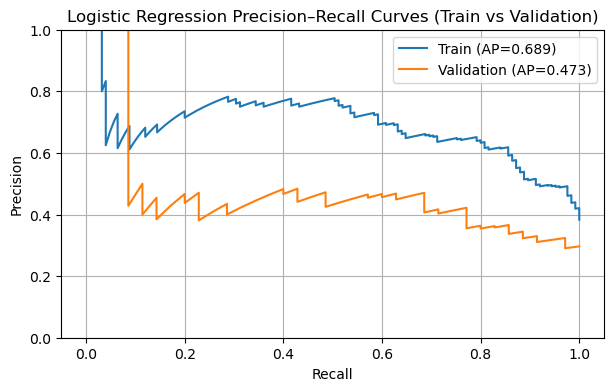


Best Threshold (max F1): 0.5584
Precision at best threshold: 0.4839
Recall at best threshold: 0.4286
F1-score at best threshold: 0.4545


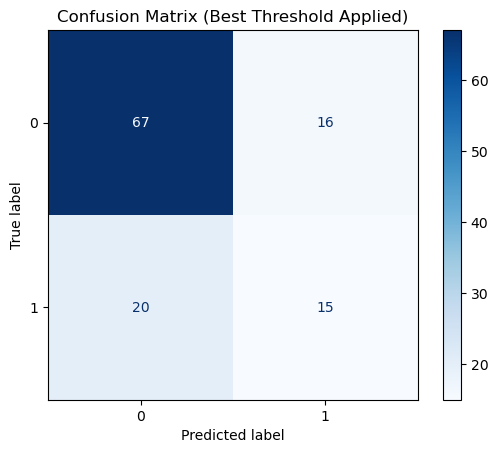

In [6]:
# Assuming you already have X_train_scaled, X_val_scaled, y_train, y_val
best_model,= UMP_predictor_model(x_train, y_train, x_val, y_val),#target_precision=0.60)


In [7]:
#Create parameter space plots

#groups = 

In [8]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# from sklearn.preprocessing import StandardScaler
# from sklearn.experimental import enable_halving_search_cv  # noqa
# from sklearn.model_selection import HalvingGridSearchCV
# from sklearn.metrics import (
#     precision_recall_curve,
#     precision_score, recall_score, confusion_matrix,
#     ConfusionMatrixDisplay
# )

# from imblearn.over_sampling import ADASYN
# from xgboost import XGBClassifier


# def UMP_predictor_model(X_train, y_train, X_valid, y_valid, target_precision=0.90):
#     """
#     High-precision classifier using ADASYN + XGBoost + threshold tuning.
#     """

#     # -------------------------
#     # 1. Oversample Hard Minority Regions with ADASYN
#     # -------------------------
#     adasyn = ADASYN(random_state=42, n_neighbors=5)
#     X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

#     # -------------------------
#     # 2. Scale data AFTER resampling
#     # -------------------------
#     scaler = StandardScaler()
#     X_train_res = scaler.fit_transform(X_train_res)
#     X_valid_scaled = scaler.transform(X_valid)

#     # -------------------------
#     # 3. Model + Halving Grid Search
#     # -------------------------
#     # Class imbalance adjustment for XGBoost
#     scale_pos_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum()

#     base_model = XGBClassifier(
#         scale_pos_weight=scale_pos_weight,
#         eval_metric="logloss",
#     )

#     param_grid = {
#         "max_depth": [2, 3, 4, 5],
#         "learning_rate": [0.01],
#         "n_estimators": [100, 200, 300],
#         "subsample": [0.7, 0.9, 1.0],
#         "colsample_bytree": [0.7, 1.0]
#     }

#     search = HalvingGridSearchCV(
#         estimator=base_model,
#         param_grid=param_grid,
#         scoring="precision",
#         cv=5,
#         factor=3,
#         verbose=1
#     )

#     search.fit(X_train_res, y_train_res)
#     best_model = search.best_estimator_

#     print("\nBest Hyperparameters Found:")
#     print(search.best_params_)

#     # -------------------------
#     # 4. Validation Probability Scores
#     # -------------------------
#     y_probs = best_model.predict_proba(X_valid_scaled)[:, 1]

#     precisions, recalls, thresholds = precision_recall_curve(y_valid, y_probs)

#     # Pick threshold: highest recall such that precision >= target_precision
#     idx = np.where(precisions >= target_precision)[0]
#     if len(idx) > 0:
#         i = idx[np.argmax(recalls[idx])]
#         best_threshold = thresholds[i] if i < len(thresholds) else 0.5
#     else:
#         best_threshold = 0.5

#     print(f"\nSelected Threshold = {best_threshold:.3f}")

#     y_pred = (y_probs >= best_threshold).astype(int)

#     # -------------------------
#     # 5. Performance Evaluation
#     # -------------------------
#     print(f"Precision: {precision_score(y_valid, y_pred):.4f}")
#     print(f"Recall:    {recall_score(y_valid, y_pred):.4f}")

#     cm = confusion_matrix(y_valid, y_pred)
#     plt.figure(figsize=(5, 4))
#     ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
#     plt.title(f"Confusion Matrix (threshold={best_threshold:.2f})")
#     plt.show()

#     # -------------------------
#     # 6. Precision-Recall Curve
#     # -------------------------
#     plt.figure(figsize=(7, 5))
#     plt.plot(recalls, precisions)
#     plt.xlabel("Recall")
#     plt.ylabel("Precision")
#     plt.title("Precision–Recall Curve (XGBoost + ADASYN)")
#     plt.grid(True)
#     plt.show()

#     return best_model, scaler, best_threshold


In [9]:
# # Assuming you already have X_train_scaled, X_val_scaled, y_train, y_val
# best_model,scaler, best_threshold = UMP_predictor_model(x_train, y_train, x_val, y_val,target_precision=0.80)


# Feed Forward Neural Network

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer, average_precision_score
)

def UMP_predictor_ffnn_model(X_train, y_train, X_val, y_val):
    # Base MLP model
    model = MLPClassifier(
        activation='relu',
        solver='adam',
        max_iter=10000,
        random_state=42
    )

    # Hyperparameter grid
    param_grid = {
        'hidden_layer_sizes': [
            (32,32,16), (32,16,16), (32,32,32),
            (32,), (64,32), (32,16,8)
        ],
        'alpha': [0.0001, 0.001, 0.01, 0.1]
    }

    # F1 scoring
    scorer = make_scorer(f1_score, zero_division=0)

    # Hyperparameter search
    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scorer,
        cv=5,
        factor=3,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    print("\nBest Hyperparameters:", search.best_params_)

    # ---- Get predicted probabilities ----
    y_train_scores = best_model.predict_proba(X_train)[:, 1]
    y_val_scores   = best_model.predict_proba(X_val)[:, 1]

    # ---- Precision–Recall curves ----
    prec_train, rec_train, _ = precision_recall_curve(y_train, y_train_scores)
    prec_val, rec_val, thresholds_val = precision_recall_curve(y_val, y_val_scores)

    # ---- Plot both curves ----
    plt.figure(figsize=(7,4))
    plt.plot(rec_train, prec_train, label=f"Train (AP={average_precision_score(y_train, y_train_scores):.3f})")
    plt.plot(rec_val, prec_val, label=f"Validation (AP={average_precision_score(y_val, y_val_scores):.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("FFNN Precision–Recall Curves (Train vs Validation)")
    plt.legend()
    plt.ylim(0,1)
    plt.grid(True)
    plt.show()

    # ---- Best threshold on validation ----
    f1_scores = 2 * (prec_val * rec_val) / (prec_val + rec_val + 1e-9)
    prec_val = prec_val[:-1]
    rec_val = rec_val[:-1]
    f1_scores = f1_scores[:-1]
    mask = rec_val >= 0.15
    candidate_precisions = prec_val[mask]
    candidate_thresholds = thresholds_val[mask]
    best_index = np.argmax(candidate_precisions)
    best_threshold = candidate_thresholds[best_index]

    print(f"\nBest Threshold (max F1): {best_threshold:.4f}")
    print(f"Precision at best threshold: {candidate_precisions[best_index]:.4f}")
    print(f"Recall at best threshold: {rec_val[mask][best_index]:.4f}")
    print(f"F1-score at best threshold: {f1_scores[mask][best_index]:.4f}")

    # ---- Apply threshold ----
    y_train_pred = (y_train_scores >= best_threshold).astype(int)
    y_val_pred   = (y_val_scores >= best_threshold).astype(int)

    # ---- Confusion Matrices ----
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_val   = confusion_matrix(y_val, y_val_pred)

    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    ConfusionMatrixDisplay(confusion_matrix=cm_train).plot(cmap="Blues", ax=axes[0], colorbar=False)
    axes[0].set_title("Train Confusion Matrix")
    ConfusionMatrixDisplay(confusion_matrix=cm_val).plot(cmap="Blues", ax=axes[1], colorbar=False)
    axes[1].set_title("Validation Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # ---- Precision vs Network Architecture ----
    results = search.cv_results_
    mean_scores = results['mean_test_score']
    labels = [str(h) for h in results['param_hidden_layer_sizes']]

    plt.figure(figsize=(10,4))
    plt.plot(labels, mean_scores, marker='o')
    plt.xticks(rotation=45)
    plt.xlabel("Hidden Layer Sizes")
    plt.ylabel("Cross-Validated F1 Score")
    plt.title("F1 vs Network Architecture")
    plt.grid(True)
    plt.show()

    return best_model, best_threshold


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 36
max_resources_: 326
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 24
n_resources: 36
Fitting 5 folds for each of 24 candidates, totalling 120 fits
----------
iter: 1
n_candidates: 8
n_resources: 108
Fitting 5 folds for each of 8 candidates, totalling 40 fits
----------
iter: 2
n_candidates: 3
n_resources: 324
Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best Hyperparameters: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32)}


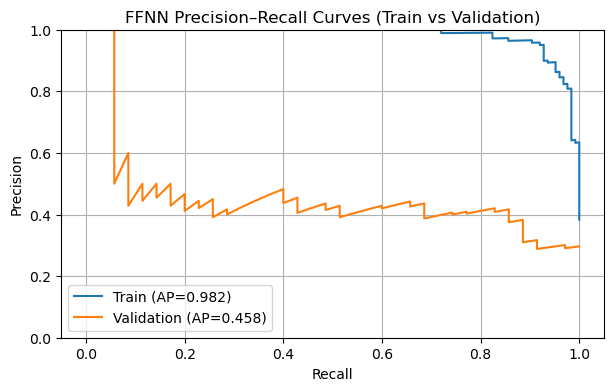


Best Threshold (max F1): 0.9897
Precision at best threshold: 0.5000
Recall at best threshold: 0.1714
F1-score at best threshold: 0.2553


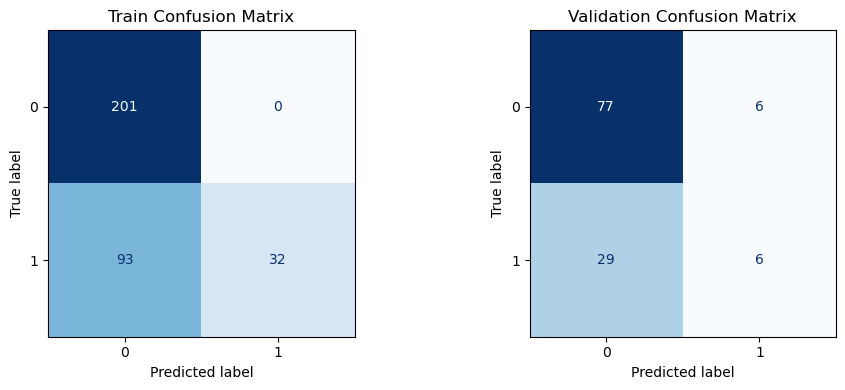

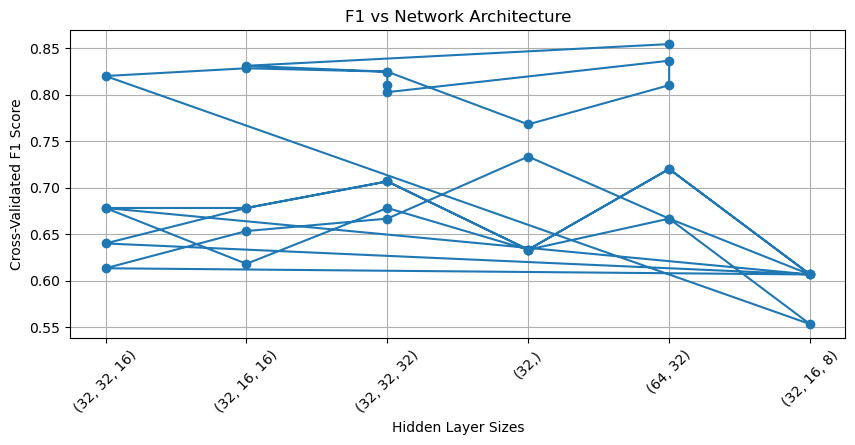

In [11]:
best_model,best_threshold = UMP_predictor_ffnn_model(x_train, y_train, x_val, y_val)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
    precision_recall_curve,
    average_precision_score
)

def UMP_predictor_knn_model(X_train, y_train, X_val, y_val):
    # Define base KNN model
    model = KNeighborsClassifier()

    # Hyperparameter grid
    param_grid = {
        'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    }

    precision_scorer = make_scorer(precision_score, zero_division=0)

    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=precision_scorer,
        cv=5,
        factor=2,
        min_resources=10,
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    print("\nBest Hyperparameters:", search.best_params_)

    # ---- Predicted probabilities ----
    y_train_scores = best_model.predict_proba(X_train)[:, 1]
    y_val_scores   = best_model.predict_proba(X_val)[:, 1]

    # ---- Precision–Recall curves ----
    prec_train, rec_train, _ = precision_recall_curve(y_train, y_train_scores)
    prec_val, rec_val, thresholds_val = precision_recall_curve(y_val, y_val_scores)

    # ---- Plot both curves ----
    plt.figure(figsize=(7,4))
    plt.plot(rec_train, prec_train, label=f"Train (AP={average_precision_score(y_train, y_train_scores):.3f})")
    plt.plot(rec_val, prec_val, label=f"Validation (AP={average_precision_score(y_val, y_val_scores):.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("KNN Precision–Recall Curves (Train vs Validation)")
    plt.legend()
    plt.ylim(0,1)
    plt.grid(True)
    plt.show()

    # ---- Best threshold on validation ----
    f1_scores = 2 * (prec_val * rec_val) / (prec_val + rec_val + 1e-12)
    prec_val = prec_val[:-1]
    rec_val = rec_val[:-1]
    f1_scores = f1_scores[:-1]
    mask = rec_val >= 0.15
    candidate_precisions = prec_val[mask]
    candidate_thresholds = thresholds_val[mask]
    best_index = np.argmax(candidate_precisions)
    best_threshold = candidate_thresholds[best_index]

    print(f"\nBest Threshold (max F1): {best_threshold:.4f}")
    print(f"Precision at best threshold: {candidate_precisions[best_index]:.4f}")
    print(f"Recall at best threshold: {rec_val[mask][best_index]:.4f}")
    print(f"F1-score at best threshold: {f1_scores[mask][best_index]:.4f}")

    # ---- Apply threshold ----
    y_train_pred = (y_train_scores >= best_threshold).astype(int)
    y_val_pred   = (y_val_scores >= best_threshold).astype(int)

    # ---- Confusion Matrices ----
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_val   = confusion_matrix(y_val, y_val_pred)

    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    ConfusionMatrixDisplay(confusion_matrix=cm_train).plot(cmap="Blues", ax=axes[0], colorbar=False)
    axes[0].set_title("Train Confusion Matrix")
    ConfusionMatrixDisplay(confusion_matrix=cm_val).plot(cmap="Blues", ax=axes[1], colorbar=False)
    axes[1].set_title("Validation Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # --- Precision vs n_neighbors ---
    results = search.cv_results_
    k_values = results['param_n_neighbors']
    mean_precisions = results['mean_test_score']

    plt.figure(figsize=(7, 4))
    plt.plot(k_values, mean_precisions, marker='o')
    plt.xlabel("n_neighbors (k)")
    plt.ylabel("Cross-Validated Precision")
    plt.title("Precision vs Number of Neighbors (k)")
    plt.grid(True)
    plt.show()

    return best_model, best_threshold

n_iterations: 6
n_required_iterations: 6
n_possible_iterations: 6
min_resources_: 10
max_resources_: 326
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 36
n_resources: 10
Fitting 5 folds for each of 36 candidates, totalling 180 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\fderi\.conda\e

----------
iter: 1
n_candidates: 18
n_resources: 20
Fitting 5 folds for each of 18 candidates, totalling 90 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.2  0.2  0.2  0.2  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.    nan  nan  nan 0.    nan  nan  nan 0.    nan  nan  nan
 0.    nan  nan  nan 0.    nan  nan  nan 0.5  0.2  0.4  0.2  0.3  0.2
 0.4  0.2  0.4  0.2  0.2  0.   0.   0.05 0.5  0.5  0.5  0.5 ]
  warnings.warn(
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the train scores are non-finite: [1.         1.         1.         1.         0.5        1.
 0.6        1.         0.46666667 1.         0.46666667 1.
 0.125      1.         0.125      1.         0.125             nan
        nan        nan 0.2               nan        nan        nan
 0.2               nan        nan        nan 0.2               nan
        nan        nan 0.2               nan        nan        nan
 1.         0.692857

----------
iter: 2
n_candidates: 9
n_resources: 40
Fitting 5 folds for each of 9 candidates, totalling 45 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.2        0.2        0.2        0.2        0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.                nan
        nan        nan 0.                nan        nan        nan
 0.                nan        nan        nan 0.                nan
        nan        nan 0.                nan        nan        nan
 0.5        0.2        0.4        0.2        0.3        0.2
 0.4        0.2        0.4        0.2        0.2        0.
 0.         0.05       0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.46666667 0.48333333 0.49714286
 0.49714286 0.49714286 0.49714286]
  warnings.warn(
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the train scores are non-finite: [1.        

----------
iter: 3
n_candidates: 5
n_resources: 80
Fitting 5 folds for each of 5 candidates, totalling 25 fits


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.2        0.2        0.2        0.2        0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.                nan
        nan        nan 0.                nan        nan        nan
 0.                nan        nan        nan 0.                nan
        nan        nan 0.                nan        nan        nan
 0.5        0.2        0.4        0.2        0.3        0.2
 0.4        0.2        0.4        0.2        0.2        0.
 0.         0.05       0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.46666667 0.48333333 0.49714286
 0.49714286 0.49714286 0.49714286 0.75238095 0.75238095 0.7147619
 0.78777778 0.73452381]
  warnings.warn(
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One 

----------
iter: 4
n_candidates: 3
n_resources: 160
Fitting 5 folds for each of 3 candidates, totalling 15 fits
----------
iter: 5
n_candidates: 2
n_resources: 320
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Best Hyperparameters: {'n_neighbors': 1, 'p': 2, 'weights': 'distance'}


c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.2        0.2        0.2        0.2        0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.                nan
        nan        nan 0.                nan        nan        nan
 0.                nan        nan        nan 0.                nan
        nan        nan 0.                nan        nan        nan
 0.5        0.2        0.4        0.2        0.3        0.2
 0.4        0.2        0.4        0.2        0.2        0.
 0.         0.05       0.5        0.5        0.5        0.5
 0.5        0.5        0.5        0.46666667 0.48333333 0.49714286
 0.49714286 0.49714286 0.49714286 0.75238095 0.75238095 0.7147619
 0.78777778 0.73452381 0.85628205 0.85628205 0.83212121 0.86308155
 0.86308155]
  warnings.warn(
c:\Users\fderi\.conda\envs\sciML\Lib\site-packages\sk

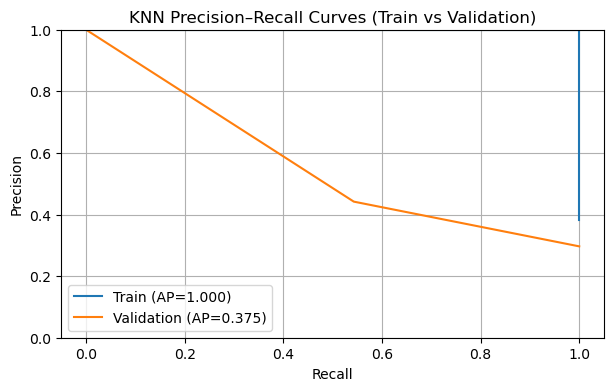


Best Threshold (max F1): 1.0000
Precision at best threshold: 0.4419
Recall at best threshold: 0.5429
F1-score at best threshold: 0.4872


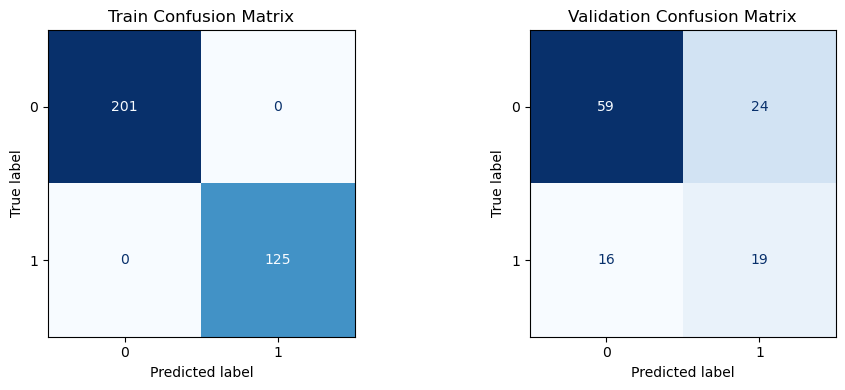

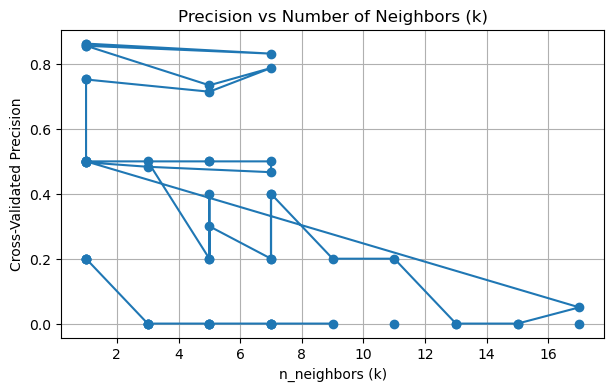

In [13]:
best_model = UMP_predictor_knn_model(x_train, y_train, x_val, y_val)

# GB Tree

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer
)


def UMP_predictor_gbt_model(X_train, y_train, X_val, y_val):

    # ---- Base Gradient Boosted Tree Model ----
    model = GradientBoostingClassifier(random_state=42)

    # ---- Hyperparameter grid ----
    param_grid = {
        'n_estimators': [30, 50,64,80,90,100],
        'learning_rate': [0.01,0.03,0.04,0.05],
        'max_depth': [2,3, 4, 5],
        'subsample': [0.9, 1.0],
        'min_samples_split': [2,3,5,7],
    }


    scorer = make_scorer(precision_score, zero_division=0)

    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scorer,
        cv=3,
        factor=2,
        min_resources=10,      # start small
        max_resources=X_train.shape[0], 
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    weights = np.where(y_train == 1, 1.0, 2.0)
    best_model.fit(X_train, y_train, sample_weight=weights)

    print("\nBest Hyperparameters:", search.best_params_)

    # ---- Predicted probabilities for positive class ----
    y_scores = best_model.predict_proba(X_val)[:, 1]

    # ---- Compute Precision–Recall & Best Threshold ----
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

    precisions = precisions[:-1]
    recalls = recalls[:-1]
    f1_scores = f1_scores[:-1]
    mask = recalls >= 0.15
    candidate_precisions = precisions[mask]
    candidate_thresholds = thresholds[mask]

    best_index = np.argmax(candidate_precisions)
    best_threshold = candidate_thresholds[best_index]
    
    print(f"\nBest Threshold (max F1): {best_threshold:.4f}")
    print(f"Precision at best threshold: {candidate_precisions[best_index]:.4f}")
    print(f"Recall at best threshold: {recalls[mask][best_index]:.4f}")
    print(f"F1-score at best threshold: {f1_scores[mask][best_index]:.4f}")

    # ---- Apply threshold ----
    y_pred = (y_scores >= best_threshold).astype(int)

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (Best Threshold Applied)")
    plt.show()

    # ---- Precision–Recall Curve ----
    plt.figure(figsize=(7,4))
    plt.plot(recalls, precisions, linewidth=2)
    plt.scatter(recalls[best_index], precisions[best_index],
                color='red', s=80,
                label=f"Best Threshold = {best_threshold:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("GB Tree Precision–Recall Curve")
    plt.legend()
    plt.ylim(0,1)
    plt.grid(True)
    plt.show()

    # ---- Hyperparameter performance visualization ----
    results = search.cv_results_
    mean_f1 = results['mean_test_score']

    # Create labels based on (n_estimators, learning_rate, max_depth)
    labels = [
        f"{results['param_n_estimators'][i]}, "
        f"{results['param_learning_rate'][i]}, "
        f"{results['param_max_depth'][i]}"
        for i in range(len(mean_f1))
    ]

    plt.figure(figsize=(12,4))
    plt.plot(labels, mean_f1, marker='o')
    plt.xticks(rotation=75)
    plt.xlabel("(n_estimators, learning_rate, max_depth)")
    plt.ylabel("Cross-Validated F1 Score")
    plt.title("Gradient Boosted Tree Hyperparameter Results")
    plt.grid(True)
    plt.show()

    return best_model, best_threshold


In [15]:
from sklearn.metrics import average_precision_score
from sklearn.model_selection import cross_val_predict


def UMP_predictor_gbt_model(X_train, y_train, X_val, y_val):
    # ---- Base Gradient Boosted Tree Model ----
    model = GradientBoostingClassifier(random_state=42)

    # ---- Hyperparameter grid ----
    param_grid = {
        'n_estimators': [10],
        'learning_rate': [0.05],
        'max_depth': [3],
        'subsample': [0.7,0.72,0.73,0.75],
        'min_samples_split': [15,16,17],
        'min_samples_leaf': [7],
        #'max_features': ['sqrt', 'log2']
    }

    #Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 7, 'min_samples_split': 15 or 17, 'n_estimators': 10, 'subsample': 0.7}
    #colorColorY
    #Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 7, 'min_samples_split': 17, 'n_estimators': 10, 'subsample': 0.73}
    scorer = make_scorer(precision_score, zero_division=0)

    search = HalvingGridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scorer,
        cv=3,
        factor=2,
        min_resources=10,
        max_resources=X_train.shape[0],
        verbose=1
    )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    #weights = np.where(y_train == 1, 1.0, 2.0)
    best_model.fit(X_train, y_train)

    print("\nBest Hyperparameters:", search.best_params_)

    # ---- Predicted probabilities ----
    y_train_scores = best_model.predict_proba(X_train)[:, 1]
    y_val_scores   = best_model.predict_proba(X_val)[:, 1]

    y_train_cv_scores = cross_val_predict(best_model, X_train, y_train,
                                      cv=3, method="predict_proba")[:,1]

    prec_train, rec_train, _ = precision_recall_curve(y_train, y_train_cv_scores)
    prec_val, rec_val, thresholds_val = precision_recall_curve(y_val, y_val_scores)

    plt.figure(figsize=(7,4))
    plt.plot(rec_train, prec_train, label=f"Train CV (AP={average_precision_score(y_train, y_train_cv_scores):.3f})")
    plt.plot(rec_val, prec_val, label=f"Validation (AP={average_precision_score(y_val, y_val_scores):.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("GB Tree Precision–Recall Curves (Train CV vs Validation)")
    plt.legend()
    plt.ylim(0,1)
    plt.grid(True)
    plt.show()

    # ---- Best threshold on validation ----
    f1_scores = 2 * (prec_val * rec_val) / (prec_val + rec_val + 1e-9)
    prec_val = prec_val[:-1]
    rec_val = rec_val[:-1]
    f1_scores = f1_scores[:-1]
    mask = rec_val >= 0.15
    candidate_precisions = prec_val[mask]
    candidate_thresholds = thresholds_val[mask]
    best_index = np.argmax(candidate_precisions)
    best_threshold = candidate_thresholds[best_index]
    
        # ---- Confusion Matrix ----
    # cm = confusion_matrix(y_val, y_train_scores)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    # disp.plot(cmap="Blues")
    # plt.title("Confusion Matrix (Best Threshold Applied)")
    # plt.show()

    print(f"\nBest Threshold (max F1): {best_threshold:.4f}")
    print(f"Precision at best threshold: {candidate_precisions[best_index]:.4f}")
    print(f"Recall at best threshold: {rec_val[mask][best_index]:.4f}")
    print(f"F1-score at best threshold: {f1_scores[mask][best_index]:.4f}")

    return best_model, best_threshold


n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 6
min_resources_: 10
max_resources_: 326
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 12
n_resources: 10
Fitting 3 folds for each of 12 candidates, totalling 36 fits
----------
iter: 1
n_candidates: 6
n_resources: 20
Fitting 3 folds for each of 6 candidates, totalling 18 fits
----------
iter: 2
n_candidates: 3
n_resources: 40
Fitting 3 folds for each of 3 candidates, totalling 9 fits
----------
iter: 3
n_candidates: 2
n_resources: 80
Fitting 3 folds for each of 2 candidates, totalling 6 fits

Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 7, 'min_samples_split': 17, 'n_estimators': 10, 'subsample': 0.75}


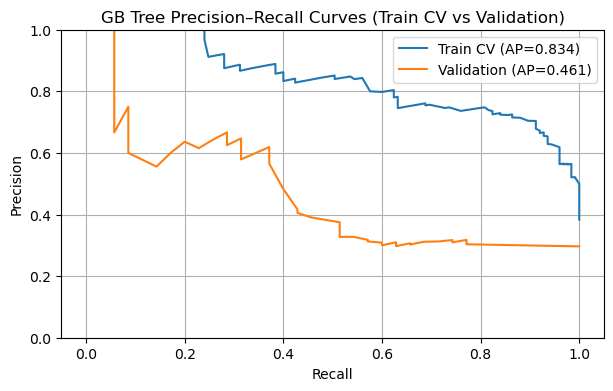


Best Threshold (max F1): 0.5048
Precision at best threshold: 0.6667
Recall at best threshold: 0.2857
F1-score at best threshold: 0.4000


In [16]:
best_model,best_threshold = UMP_predictor_gbt_model(x_train, y_train, x_val, y_val)

In [17]:
gaiagalexDat = u.read_gaia_galex_data()    


gaiagalexDat_X = gaiagalexDat[features_and_label[:-1]]
    

#y_new_pred = best_model.predict()

#but if we want probabilities itll be:

#y_new_proba = best_model.predict_proba(new_data_xValues)[:, 1]
# then, e.g.
#y_new_pred = (y_new_proba >= best_threshold).astype(int)

In [18]:
gaiagalexDat_X_clean = gaiagalexDat_X.dropna(axis=0, how='any').copy()
removed_count = len(gaiagalexDat_X) - len(gaiagalexDat_X_clean)
print(f"Dropped {removed_count} rows with NaNs; remaining {len(gaiagalexDat_X_clean)} rows")


Dropped 1 rows with NaNs; remaining 1112355 rows


In [19]:
gaiagalex_X_scaled = scaler.transform(gaiagalexDat_X_clean)



In [20]:
gaiagalex_dat_preds = best_model.predict(gaiagalex_X_scaled)
gg_y_pred = (gaiagalex_dat_preds >= best_threshold).astype(int)


In [21]:
# Predict on the clean, scaled data
#gaiagalex_preds = best_model.predict(gaiagalex_X_scaled)

# Put predictions back into the original dataframe (NaN where rows were dropped)
gaiagalexDat = gaiagalexDat.copy()
gaiagalexDat['pred_UMP'] = np.nan
gaiagalexDat.loc[gaiagalexDat_X_clean.index, 'pred_UMP'] = gg_y_pred


C:\Users\fderi\AppData\Local\Temp\ipykernel_39588\907928860.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


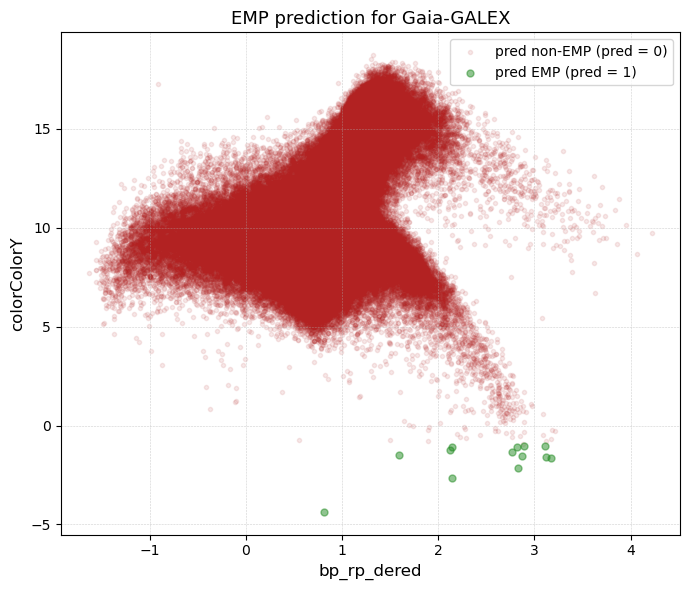

C:\Users\fderi\AppData\Local\Temp\ipykernel_39588\907928860.py:77: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


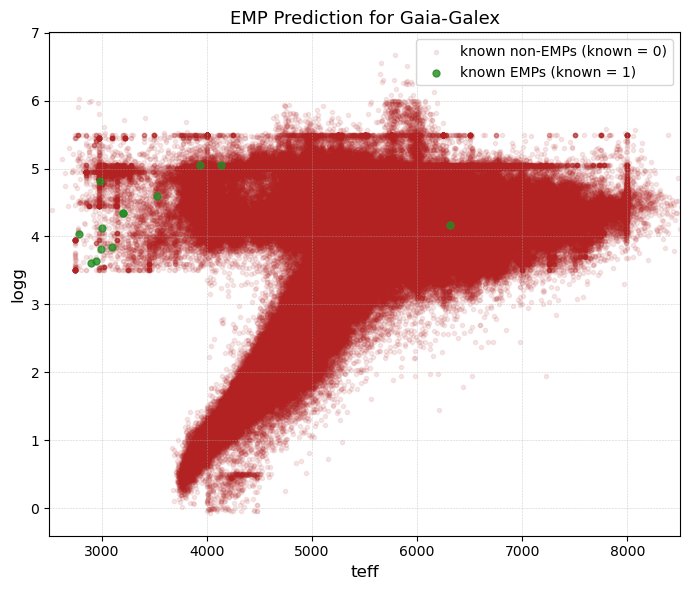

In [ ]:

#Create parameter space plots 

def plot_emp_predictions(x_vals_original, emp_predict, y_val=[]):

    # x_vals_original: array of [Teff, logg, bp_rp_dered, colorColorY]
    # emp_predict: 0/1 array, same length as x_vals_original

    x_vals_original = np.asarray(x_vals_original)
    emp_predict = np.asarray(emp_predict)

    bp_rp = x_vals_original[:, 2]
    colorColorY = x_vals_original[:, 4]

    is_emp = emp_predict == 1
    not_emp = emp_predict == 0

    plt.figure(figsize=(7, 6))

    # plot predicted non-EMPs
    plt.scatter(
        bp_rp[not_emp],
        colorColorY[not_emp],
        s=9,
        alpha=0.1,
        color="firebrick",
        label="pred non-EMP (pred = 0)")

    # plot predicted EMPs
    plt.scatter(
        bp_rp[is_emp],
        colorColorY[is_emp],
        s=25,
        alpha=0.5,
        color="forestgreen",
        label="pred EMP (pred = 1)")

    plt.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
    plt.xlabel("bp_rp_dered", fontsize=12)
    plt.ylabel("colorColorY", fontsize=12)
    plt.title("EMP prediction for Gaia-GALEX", fontsize=13)
    plt.legend(frameon=True, fontsize=10)
    plt.tight_layout()
    plt.xlim()
    plt.ylim()
    #plt.ylim(-3,2)
    plt.show()


    plt.figure(figsize=(7, 6))

    teff = x_vals_original[:,0]
    logg = x_vals_original[:, 1]

    # plot other things
    plt.scatter(
        teff[not_emp],
        logg[not_emp],
        s=9,
        alpha=0.1,
        color="firebrick",
        label="pred non-EMP (pred = 0)")

    # plot predicted EMPs
    plt.scatter(
        teff[is_emp],
        logg[is_emp],
        s=25,
        alpha=0.8,
        color="forestgreen",
        label="pred EMP (pred = 1)")

    plt.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
    plt.xlabel("teff", fontsize=12)
    plt.ylabel("logg", fontsize=12)
    plt.title("EMP Prediction for Gaia-Galex", fontsize=13)
    plt.legend(frameon=True, fontsize=10)
    plt.tight_layout()
    plt.xlim(2500,8500)
    
    plt.show()


gaiagalex_rescaled = scaler.inverse_transform(gaiagalex_X_scaled) 
#print(x_vals_original) # Teff, logg, bp_rp_dered, colorColorY
#print(emp_predict)

#emp_predictLogReg = best_model.predict(x_val) 
plot_emp_predictions(gaiagalex_rescaled, gg_y_pred)



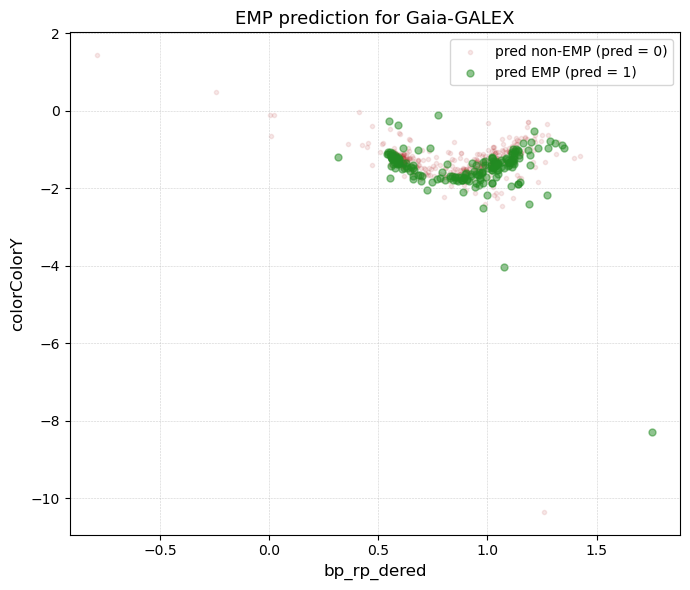

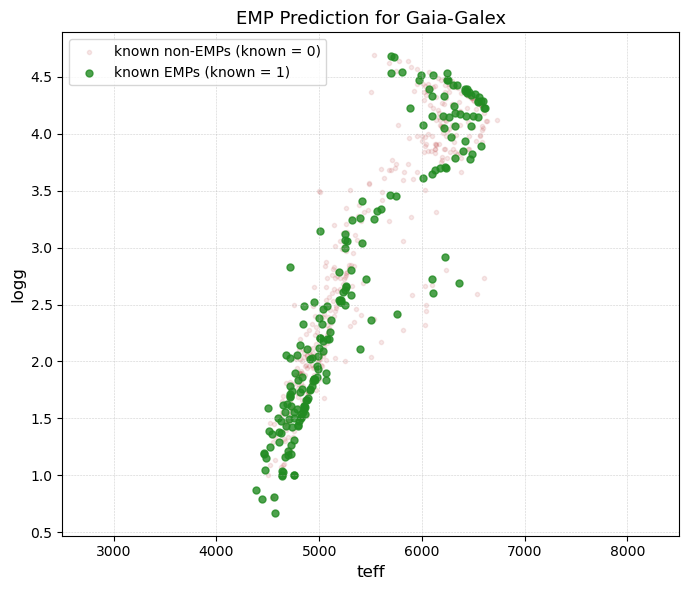

In [23]:
X = selected_data
y = selected_data['UMP_flag'].copy()

plot_emp_predictions(X,y)